In [62]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import snscrape
import yfinance as yf
import plotly.express as px
import plotly.subplots as pss
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from tqdm.notebook import tqdm
import requests
from bs4 import BeautifulSoup
from textblob import TextBlob
from gnews import GNews

In [63]:
msft=yf.Ticker("MSFT")
info=msft.info
print(type(info),"\n",info)

<class 'dict'> 
 {'address1': 'One Microsoft Way', 'city': 'Redmond', 'state': 'WA', 'zip': '98052-6399', 'country': 'United States', 'phone': '425 882 8080', 'website': 'https://www.microsoft.com', 'industry': 'Software - Infrastructure', 'industryKey': 'software-infrastructure', 'industryDisp': 'Software - Infrastructure', 'sector': 'Technology', 'sectorKey': 'technology', 'sectorDisp': 'Technology', 'longBusinessSummary': 'Microsoft Corporation develops and supports software, services, devices, and solutions worldwide. The Productivity and Business Processes segment offers Microsoft 365 commercial, enterprise mobility + security, windows commercial, power BI, exchange, sharepoint, Microsoft teams, security and compliance, and copilot; Microsoft 365 commercial products, such as Windows commercial on-premises and office licensed services; Microsoft 365 consumer products and cloud services, including Microsoft 365 consumer subscriptions, office licensed on-premises, and other consumer 

In [64]:
print(info.keys())

dict_keys(['address1', 'city', 'state', 'zip', 'country', 'phone', 'website', 'industry', 'industryKey', 'industryDisp', 'sector', 'sectorKey', 'sectorDisp', 'longBusinessSummary', 'fullTimeEmployees', 'companyOfficers', 'auditRisk', 'boardRisk', 'compensationRisk', 'shareHolderRightsRisk', 'overallRisk', 'governanceEpochDate', 'compensationAsOfEpochDate', 'irWebsite', 'executiveTeam', 'maxAge', 'priceHint', 'previousClose', 'open', 'dayLow', 'dayHigh', 'regularMarketPreviousClose', 'regularMarketOpen', 'regularMarketDayLow', 'regularMarketDayHigh', 'dividendRate', 'dividendYield', 'exDividendDate', 'payoutRatio', 'fiveYearAvgDividendYield', 'beta', 'trailingPE', 'forwardPE', 'volume', 'regularMarketVolume', 'averageVolume', 'averageVolume10days', 'averageDailyVolume10Day', 'bid', 'ask', 'bidSize', 'askSize', 'marketCap', 'nonDilutedMarketCap', 'fiftyTwoWeekLow', 'fiftyTwoWeekHigh', 'allTimeHigh', 'allTimeLow', 'priceToSalesTrailing12Months', 'fiftyDayAverage', 'twoHundredDayAverage', 

In [65]:
info['ebitda']

175258992640

In [66]:
info['totalRevenue']

305453006848

In [67]:
hist=msft.history(period="1y")
hist

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-03-03 00:00:00-05:00,395.789987,395.789987,383.226168,385.538452,23007700,0.0,0.0
2025-03-04 00:00:00-05:00,380.487123,389.597371,378.105363,385.657532,29342900,0.0,0.0
2025-03-05 00:00:00-05:00,386.381982,398.618322,385.856010,397.973236,23433100,0.0,0.0
2025-03-06 00:00:00-05:00,391.284478,399.094681,389.696628,393.874664,23304600,0.0,0.0
2025-03-07 00:00:00-05:00,389.339370,391.800508,382.610882,390.321838,22034100,0.0,0.0
...,...,...,...,...,...,...,...
2026-02-24 00:00:00-05:00,384.140015,389.359985,381.709991,389.000000,33884700,0.0,0.0
2026-02-25 00:00:00-05:00,390.529999,401.470001,390.160004,400.600006,43625500,0.0,0.0
2026-02-26 00:00:00-05:00,404.709991,407.489990,398.739990,401.720001,34405900,0.0,0.0


In [68]:
hist.isnull().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

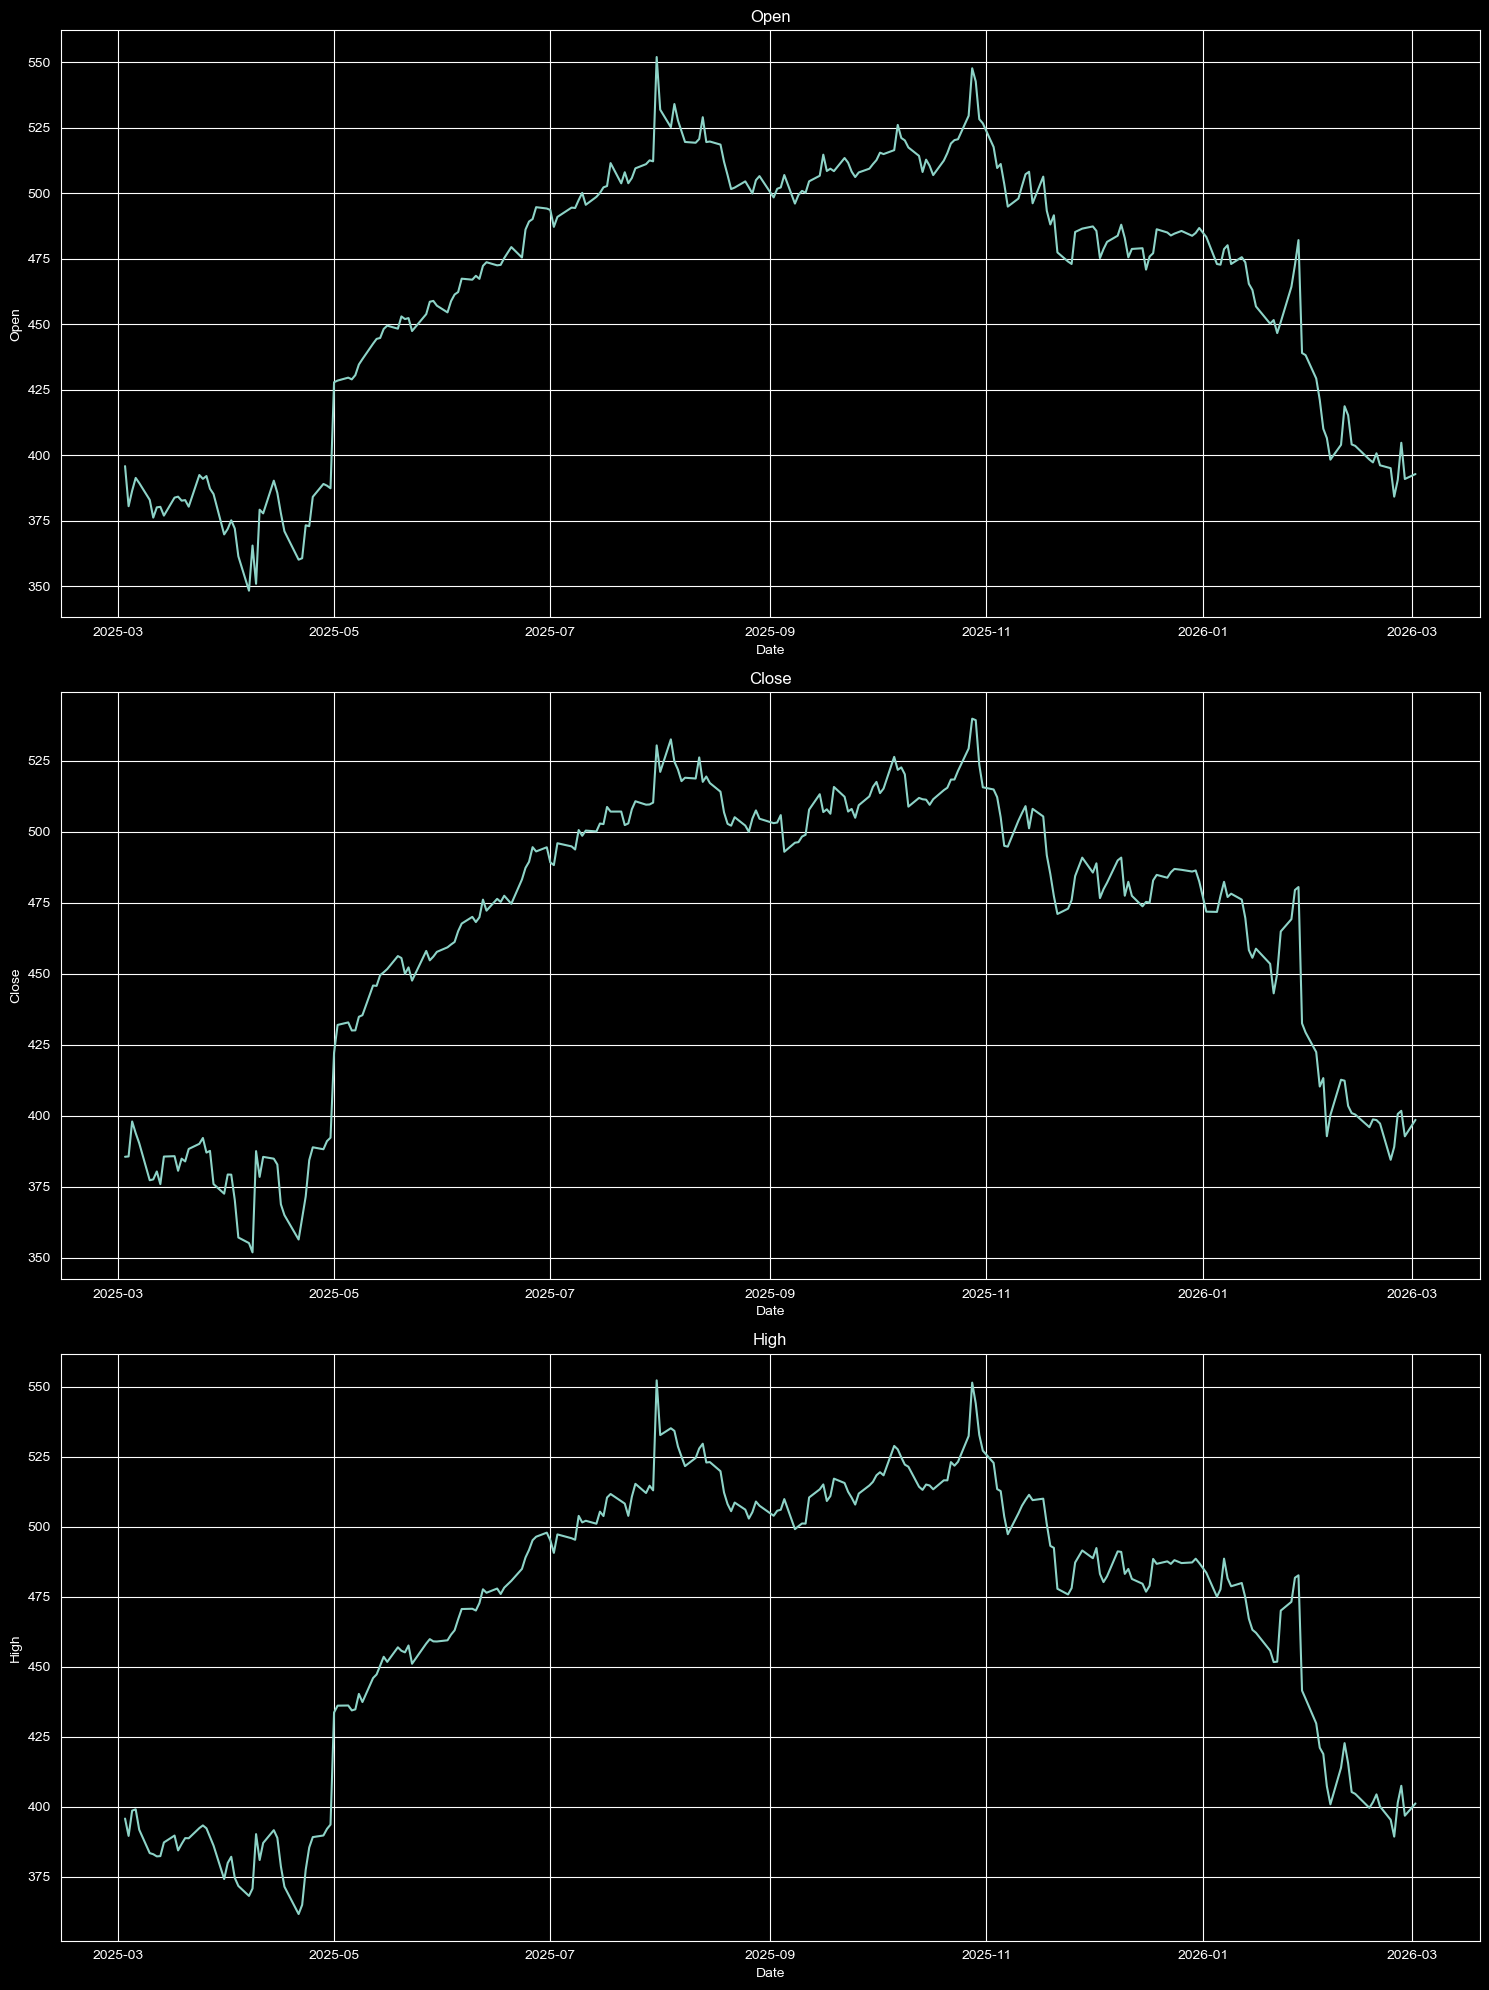

In [69]:
fig,axes=plt.subplots(3,1,figsize=(15,20))
sns.lineplot(data=hist,x=hist.index,y='Open',ax=axes[0])
axes[0].set_title('Open')
sns.lineplot(data=hist,x=hist.index,y='Close',ax=axes[1])
axes[1].set_title('Close')
sns.lineplot(data=hist,x=hist.index,y='High',ax=axes[2])
axes[2].set_title('High')
plt.tight_layout()
plt.show()

In [70]:
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=hist.index, z=hist['Low'],y=hist['Volume'],line=dict(color='red'),mode='lines'))
fig.add_trace(go.Scatter3d(x=hist.index, z=hist['Close'],y=hist['Volume'],line=dict(color='blue'),mode='lines'))
fig.show()

In [71]:
dir(go)

['AngularAxis',
 'Annotation',
 'Annotations',
 'Bar',
 'Barpolar',
 'Box',
 'Candlestick',
 'Carpet',
 'Choropleth',
 'Choroplethmap',
 'Choroplethmapbox',
 'ColorBar',
 'Cone',
 'Contour',
 'Contourcarpet',
 'Contours',
 'Data',
 'Densitymap',
 'Densitymapbox',
 'ErrorX',
 'ErrorY',
 'ErrorZ',
 'Figure',
 'FigureWidget',
 'Font',
 'Frame',
 'Frames',
 'Funnel',
 'Funnelarea',
 'Heatmap',
 'Heatmapgl',
 'Histogram',
 'Histogram2d',
 'Histogram2dContour',
 'Histogram2dcontour',
 'Icicle',
 'Image',
 'Indicator',
 'Isosurface',
 'Layout',
 'Legend',
 'Line',
 'Margin',
 'Marker',
 'Mesh3d',
 'Ohlc',
 'Parcats',
 'Parcoords',
 'Pie',
 'Pointcloud',
 'RadialAxis',
 'Sankey',
 'Scatter',
 'Scatter3d',
 'Scattercarpet',
 'Scattergeo',
 'Scattergl',
 'Scattermap',
 'Scattermapbox',
 'Scatterpolar',
 'Scatterpolargl',
 'Scattersmith',
 'Scatterternary',
 'Scene',
 'Splom',
 'Stream',
 'Streamtube',
 'Sunburst',
 'Surface',
 'Table',
 'Trace',
 'Treemap',
 'Violin',
 'Volume',
 'Waterfall',
 '

In [72]:
stonks = [
    "^GSPC",
    "ETSY",
    "PINS",
    "SQ",
    "SHOP",
    "O",
    "MELI",
    "ISRG",
    "DIS",
    "BRK-B",
    "AMZN",
    "ZM",
    "PFE",
    "CLX",
    "DPZ",
    "RTX",
]

In [73]:
stonk_ob=yf.Tickers(stonks)
stonk_ob

yfinance.Tickers object <^GSPC,ETSY,PINS,SQ,SHOP,O,MELI,ISRG,DIS,BRK-B,AMZN,ZM,PFE,CLX,DPZ,RTX>

In [74]:
df=stonk_ob.history(period='1y')

03/03/2026 02:35:12 AM - ['SQ']: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")


In [75]:
t=df[('Close')].columns
len(t)

16

In [76]:
df['Close']['AMZN']

Date
2025-03-03    205.020004
2025-03-04    203.800003
2025-03-05    208.360001
2025-03-06    200.699997
2025-03-07    199.250000
                 ...    
2026-02-24    208.559998
2026-02-25    210.639999
2026-02-26    207.919998
2026-02-27    210.000000
2026-03-02    208.389999
Name: AMZN, Length: 251, dtype: float64

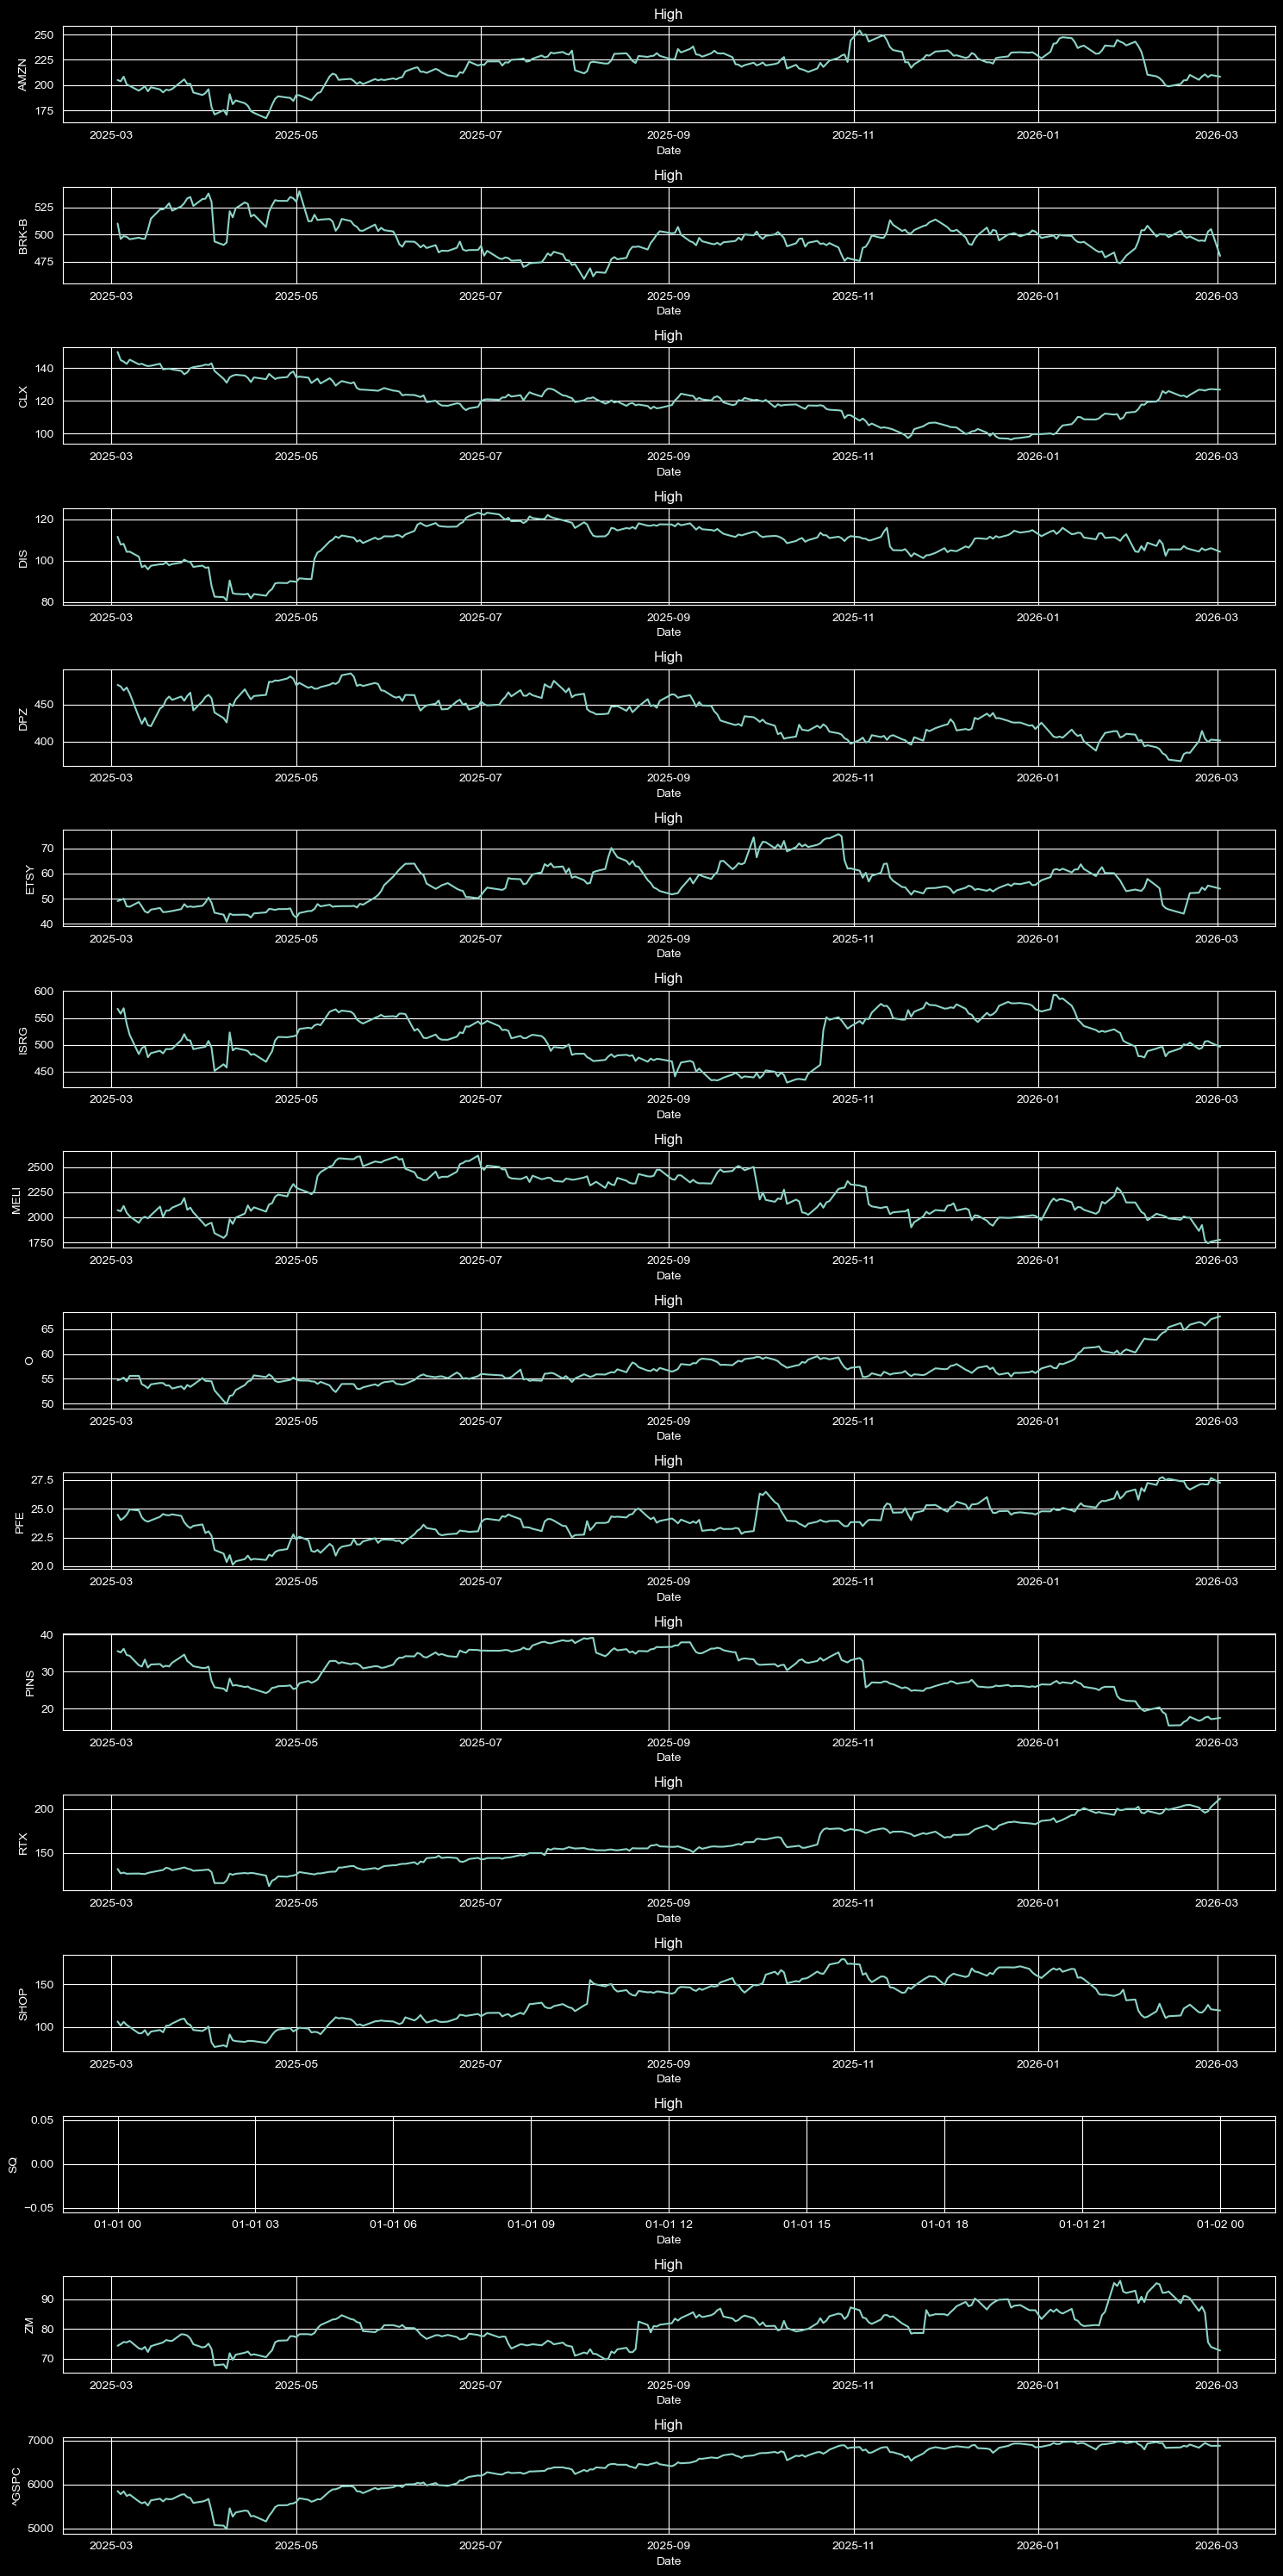

In [77]:
fig,axes=plt.subplots(len(t),1,figsize=(15,30))
for i,n in enumerate(t):
    sns.lineplot(x=df.index,y=df['Close'][n],ax=axes[i])
    axes[i].set_title('High')
plt.tight_layout()
plt.show()

In [78]:
fig=go.Figure()
fig.add_trace(go.Candlestick(x=hist.index,high=hist['High'],low=hist['Low'],open=hist['Open'],close=hist['Close']))
fig.update_layout(height=900, showlegend=False)
fig.show()

In [91]:
google_news = GNews(start_date=(2019,11,4), end_date=(2022,11,2))
results = google_news.get_news('AAPL')

news_df = pd.DataFrame(results)
news_df.shape

(100, 5)

In [92]:
news_df.head()

,title,description,published date,url,publisher
0,Why Apple (AAPL) Stock is a Strong Buy Heading...,Why Apple (AAPL) Stock is a Strong Buy Heading...,"Fri, 17 Jan 2020 08:00:00 GMT",https://news.google.com/rss/articles/CBMifkFVX...,"{'href': 'https://finance.yahoo.com', 'title':..."
1,Chart points to a nearly 20% rally for Apple a...,Chart points to a nearly 20% rally for Apple a...,"Wed, 27 Jan 2021 08:00:00 GMT",https://news.google.com/rss/articles/CBMiqgFBV...,"{'href': 'https://www.cnbc.com', 'title': 'CNBC'}"
2,Should Apple (AAPL) Split Its Stock? - Nasdaq,Should Apple (AAPL) Split Its Stock? Nasdaq,"Mon, 06 Jan 2020 08:00:00 GMT",https://news.google.com/rss/articles/CBMiggFBV...,"{'href': 'https://www.nasdaq.com', 'title': 'N..."
3,Apple (AAPL) Q3 FY 2021 Earnings Report Previe...,Apple (AAPL) Q3 FY 2021 Earnings Report Previe...,"Mon, 26 Jul 2021 07:00:00 GMT",https://news.google.com/rss/articles/CBMiggFBV...,"{'href': 'https://www.investopedia.com', 'titl..."
4,Apple Inc Financial Statements – NASDAQ:AAPL -...,Apple Inc Financial Statements – NASDAQ:AAPL ...,"Wed, 24 Mar 2021 22:26:17 GMT",https://news.google.com/rss/articles/CBMid0FVX...,"{'href': 'https://www.tradingview.com', 'title..."


In [93]:
# Clean and prepare text
news_df["published date"] = pd.to_datetime(news_df["published date"])

news_df["full_text"] = (news_df["title"].fillna("") + " " +news_df["description"].fillna(""))

news_df.head()

,title,description,published date,url,publisher,full_text
0,Why Apple (AAPL) Stock is a Strong Buy Heading...,Why Apple (AAPL) Stock is a Strong Buy Heading...,2020-01-17 08:00:00,https://news.google.com/rss/articles/CBMifkFVX...,"{'href': 'https://finance.yahoo.com', 'title':...",Why Apple (AAPL) Stock is a Strong Buy Heading...
1,Chart points to a nearly 20% rally for Apple a...,Chart points to a nearly 20% rally for Apple a...,2021-01-27 08:00:00,https://news.google.com/rss/articles/CBMiqgFBV...,"{'href': 'https://www.cnbc.com', 'title': 'CNBC'}",Chart points to a nearly 20% rally for Apple a...
2,Should Apple (AAPL) Split Its Stock? - Nasdaq,Should Apple (AAPL) Split Its Stock? Nasdaq,2020-01-06 08:00:00,https://news.google.com/rss/articles/CBMiggFBV...,"{'href': 'https://www.nasdaq.com', 'title': 'N...",Should Apple (AAPL) Split Its Stock? - Nasdaq ...
3,Apple (AAPL) Q3 FY 2021 Earnings Report Previe...,Apple (AAPL) Q3 FY 2021 Earnings Report Previe...,2021-07-26 07:00:00,https://news.google.com/rss/articles/CBMiggFBV...,"{'href': 'https://www.investopedia.com', 'titl...",Apple (AAPL) Q3 FY 2021 Earnings Report Previe...
4,Apple Inc Financial Statements – NASDAQ:AAPL -...,Apple Inc Financial Statements – NASDAQ:AAPL ...,2021-03-24 22:26:17,https://news.google.com/rss/articles/CBMid0FVX...,"{'href': 'https://www.tradingview.com', 'title...",Apple Inc Financial Statements – NASDAQ:AAPL -...


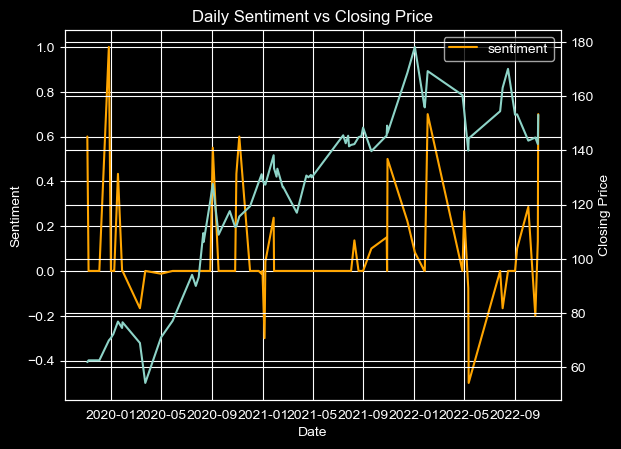

In [95]:
data = yf.download("AAPL",start="2019-11-04",end="2022-11-02",progress=True)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data.reset_index()
data["Date"] = pd.to_datetime(data["Date"]).dt.date
data = data.set_index("Date")

news_df["Date"] = pd.to_datetime(news_df["published date"]).dt.date

news_df["full_text"] = (news_df["title"].fillna("") + " " +news_df["description"].fillna(""))

def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

news_df["Sentiment_Score"] = news_df["full_text"].apply(get_sentiment)

sent_daily = news_df.groupby("Date")["Sentiment_Score"].mean()


sent_and_stock = sent_daily.to_frame("sentiment").merge(data,left_index=True,right_index=True,how="inner")


ax = sent_and_stock["sentiment"].plot(color="orange", legend="Sentiment")
ax.set_ylabel("Sentiment")

ax2 = ax.twinx()
sent_and_stock["Close"].plot(ax=ax2)
ax2.set_ylabel("Closing Price")

plt.title("Daily Sentiment vs Closing Price")
plt.show()